In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pythermalcomfort.models import pmv_ppd_iso
import warnings
warnings.filterwarnings("ignore")
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['font.size'] = 14

colors = ["#3964DF", "#E0C645","#E02927",  "#65D8DF", "#AE02DE"]

def get_dynamic_parameters(month, hour):
    # --- 1. 判断是否是睡觉时间 (例如 23:00 - 07:00) ---
    is_sleeping = (hour >= 23) or (hour < 7)

    # --- 2. 设定 Met (代谢率) ---
    if is_sleeping:
        current_met = 0.7  # 睡觉模式：产热极低
    else:
        current_met = 1.2  # 日间模式：正常静坐

    # --- 3. 设定 Clo (服装/被褥) ---
    if is_sleeping:
        # 【关键修正】睡觉必须盖被子！
        # 冬天被子厚一点 (2.5), 夏天薄被子 (1.5)
        if month in [12, 1, 2]:
            current_clo = 2.5  # 厚棉被
        elif month in [6, 7, 8]:
            current_clo = 1.5  # 毯子/薄被
        else:
            current_clo = 2.0  # 普通被子
    else:
        # 白天穿衣服 (之前的逻辑)
        if month in [11, 12, 1, 2,3,4]:
            current_clo = 1.0  # 冬装
        elif month in [6, 7, 8]:
            current_clo = 0.5  # 夏装
        else:
            current_clo = 0.75 # 春秋装
    
    return current_clo, current_met


price_ele =  pd.read_csv('london_avgprice.csv')
price_ele

,month,day,hour,ele_price
0,1,1,0.0,10.4195
1,1,1,0.5,13.1355
2,1,1,1.0,14.0525
3,1,1,1.5,8.5540
4,1,1,2.0,9.7160
...,...,...,...,...
17563,12,31,21.5,16.4570
17564,12,31,22.0,16.0860
17565,12,31,22.5,11.5885
17566,12,31,23.0,9.9575


In [2]:
def cost(P_ac, P_heat, tsa, ele_price):
    COP_cooling = -0.14 * (tsa - 273.15) + 7.31
    COP_heating = 0.07 * (tsa - 273.15) + 3.20
    P_ac = P_ac/COP_cooling*0.5
    P_heat = P_heat/COP_heating*0.5
    r = P_ac + P_heat
    r['time'] = r['time'].dt.round('min')
    r = r.rename("ele").to_dataframe().reset_index()
    r['month'] = r['time'].dt.month
    r['day'] = r['time'].dt.day
    r['hour'] = r['time'].dt.hour + r['time'].dt.minute / 60.0
    r = r.merge(ele_price, left_on=['month', 'day', 'hour'], right_on=['month', 'day', 'hour'])
    r['cost'] = r['ele'] * r['ele_price'] /500 # convert to p/m2/h
    return r

#def benefit(tbuild):
#    print(tbuild.mean().values)
#    r = 1*(abs(tbuild - 27 - 273.15) + abs(tbuild - 19 - 273.15)-8)
#    return r
def benefit(ta, tr):
    # --- 1. 动态 Clothing (clo) ---
    ta['time'] = ta['time'].dt.round('min')
    month = ta['time'].dt.month.values
    hour = ta['time'].dt.hour.values + ta['time'].dt.minute.values / 60.0
    df = pd.DataFrame({'month':month, 'hour':hour})
    df[['clo', 'met']] = df.apply(lambda row: pd.Series(get_dynamic_parameters(row['month'], row['hour'])), axis=1)
    df['ta'] = ta.values
    df['tr'] = tr.values
    df['pmv'] = df.apply(lambda row: pmv_ppd_iso(
        tdb=row['ta'] - 273.15,
        tr=row['tr'] - 273.15,
        vr=0.1,
        rh=50,
        met=row['met'],
        clo=row['clo'],
        model="7730-2005",
        limit_inputs=False
    ).pmv, axis=1)

    def benefit_func(pmv):
        if abs(pmv) <= 0.5:
            return 0
        else:
            diff = min(abs(pmv - (-0.5)), abs(pmv - 0.5))
            pmv_penalty = - diff ** 2  
            return pmv_penalty
    df['benefit'] = df.apply(lambda row: benefit_func(row['pmv']), axis=1)
    df['time'] = ta['time']
    return df


In [3]:
def reward(cost, benefit, w):
    r = - w*cost['cost'] - (1-w) * benefit['benefit']
    return r.rename("reward")

In [4]:
def get_urb_climate_df(timeslice=("2012-11", "2013-04")):
    hac_types = ["ON_WASTEHEAT", "ON"]
    city = "London"
    w = [0.3, 0.5, 0.7]
    model = ['dqn']
    p = '/home/junjieyu/Github/RL_CLMU/data/clmu_{model}_output/london-{w}_{model}_clmu_{model}_{hac_type}.nc'
    ht_roof = 21.3
    canyon_hwr = 1.13 
    A_floor = ht_roof / canyon_hwr
    A_wall  = ht_roof 

    ds_dict = {}
    for m in model:
        for weight in w:
            for hac_type in hac_types:
                ds = xr.open_dataset(p.format(model=m, w=weight, hac_type=hac_type)).isel(landunit=1).sel(time=slice(*timeslice))
                #ds = ds.sel(time=((ds['time.month'] >= 11) | (ds['time.month'] <= 4)))
                #ds = xr.open_dataset('/home/junjieyu/Github/RL_CLMU/data/outputfolder/lnd/hist/london-0.3_dqn_ON_WASTEHEAT.clm2.h0.2011-01-01-00000.nc').isel(landunit=1).sel(time=slice(*timeslice))
                ds['time'] = ds['time'].dt.round('min')
                ds = ds.sel(pft=1)
                ds_dict[f'{m}_{weight}_{hac_type}'] = ds

    ref_hac = ['off', 'on_wasteheat', 'on']
    p_ref = '/home/junjieyu/Github/RL_CLMU/data/hac_{ref_hac}/london/default.nc'
    ref_dict = {}
    for ref in ref_hac:
        ds_ref = xr.open_dataset(p_ref.format(ref_hac=ref)).isel(landunit=1).sel(time=slice(*timeslice))
        #ds_ref = ds_ref.sel(time=((ds_ref['time.month'] >= 11) | (ds_ref['time.month'] <= 4)))
        ds_ref['time'] = ds_ref['time'].dt.round('min')
        ds_ref = ds_ref.sel(pft=1)
        if ref == 'off':
            ref_dict[ref] = ds_ref
        else:
            ref_dict[ref+'_20'] = ds_ref

    ref_hac = ['on_wasteheat', 'on']
    heating_set_point = [18, 22, 24]
    p_ref = '/home/junjieyu/Github/RL_CLMU/data/hac_{ref_hac}/london/default_heating_{hp}.nc'
    for hp in heating_set_point:
        for ref in ref_hac:
            ds_ref = xr.open_dataset(p_ref.format(ref_hac=ref, hp=hp)).isel(landunit=1).sel(time=slice(*timeslice))
            #ds_ref = ds_ref.sel(time=((ds_ref['time.month'] >= 11) | (ds_ref['time.month'] <= 4)))
            ds_ref['time'] = ds_ref['time'].dt.round('min')
            ds_ref = ds_ref.sel(pft=1)
            ref_dict[ref+f'_{hp}'] = ds_ref
            
    
    urb_climate = pd.DataFrame()

    urb_climate_ls = []
    for key in ds_dict.keys():
        ds = ds_dict[key]
        _df = ds[['TSA', 'TBUILD', 'URBAN_HEAT', 'RH2M']].to_dataframe().reset_index()
        cost_df = cost(ds['URBAN_AC'], ds['URBAN_HEAT'], ds['TSA'], price_ele)
        ds['TBUILD_MRT'] = (ds['TROOF_INNER']*A_floor + ds['TSUNW_INNER']*A_wall + ds['TSHDW_INNER']*A_wall + ds['TFLOOR']*A_floor) / (A_floor + 2*A_wall + A_floor)
        benefit_df = benefit(ds['TBUILD'], ds['TBUILD_MRT'])
        _df = _df.merge(cost_df[['time', 'cost', 'ele_price']], on='time')
        _df = _df.merge(benefit_df[['time', 'benefit', 'pmv']], on='time')
        _df['model'] = key.split('_')[0] + key.split('_')[1]
        _df['hac_type'] = key.split('_')[2].lower() + ('_' + key.split('_')[3] if len(key.split('_')) > 3 else '')
        #_df_ws = ds['WASTEHEAT'].sel(pft=5).to_dataframe().reset_index()
        #_df = _df.merge(_df_ws[['time', 'WASTEHEAT']], on='time')
        urb_climate_ls.append(_df)

    for key in ref_dict.keys():
        ds = ref_dict[key]
        _df = ds[['TSA', 'TBUILD', 'URBAN_HEAT', 'RH2M']].to_dataframe().reset_index()
        cost_df = cost(ds['URBAN_AC'], ds['URBAN_HEAT'], ds['TSA'], price_ele)
        ds['TBUILD_MRT'] = (ds['TROOF_INNER']*A_floor + ds['TSUNW_INNER']*A_wall + ds['TSHDW_INNER']*A_wall + ds['TFLOOR']*A_floor) / (A_floor + 2*A_wall + A_floor)
        benefit_df = benefit(ds['TBUILD'], ds['TBUILD_MRT'])
        _df = _df.merge(cost_df[['time', 'cost', 'ele_price']], on='time')
        _df = _df.merge(benefit_df[['time', 'benefit', 'pmv']], on='time')
        _df['model'] = key.split('_')[-1].lower()
        _df['hac_type'] = key
        #_df_ws = ds['WASTEHEAT'].sel(pft=5).to_dataframe().reset_index()
        #_df = _df.merge(_df_ws[['time', 'WASTEHEAT']], on='time')
        urb_climate_ls.append(_df)

    urb_climate = pd.concat(urb_climate_ls, ignore_index=True)
    
    return urb_climate

In [5]:
urban_climate = get_urb_climate_df()
urban_climate_2012 = get_urb_climate_df(timeslice=("2011-11", "2012-04"))

In [6]:
urban_climate.to_csv('./fig_data/urban_climate_london.csv', index=False)
urban_climate_2012.to_csv('./fig_data/urban_climate_london_2012.csv', index=False)

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pythermalcomfort.models import pmv_ppd_iso
import warnings
warnings.filterwarnings("ignore")
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['font.size'] = 14

def get_processed_urb_climate_df(p):
    urban_climate = pd.read_csv('./fig_data/urban_climate_london.csv')
    urban_climate['time'] = pd.to_datetime(urban_climate['time'])
    urban_climate['model'] = urban_climate['model'].astype(str)
    urban_climate['hac_type'] = urban_climate['hac_type'].str.lower()
    return urban_climate

urban_climate = get_processed_urb_climate_df('./fig_data/urban_climate_london.csv')
urban_climate_2012 = get_processed_urb_climate_df('./fig_data/urban_climate_london_2012.csv')

In [2]:
def get_difference(urb_climate, type='mean'):
    if type == 'mean':
        urb_climate_grouped = urb_climate.groupby(['model', 'hac_type']).mean().reset_index()
    elif type == 'median':
        urb_climate_grouped = urb_climate.groupby(['model', 'hac_type']).median().reset_index()
    elif type == 'max': 
        urb_climate_grouped = urb_climate.groupby(['model', 'hac_type']).max().reset_index()
    elif type == 'min':
        urb_climate_grouped = urb_climate.groupby(['model', 'hac_type']).min().reset_index()
    else:
        raise ValueError("Invalid type. Choose from 'mean', 'median', 'max', 'min'.")
    urb_climate_grouped['hac_type'] = urb_climate_grouped['hac_type'].str.lower()
    urb_climate_grouped_on = urb_climate_grouped[(urb_climate_grouped['hac_type'].str.contains('on')) &
                                                (~urb_climate_grouped['hac_type'].str.contains('on_wasteheat'))].drop(columns=['hac_type'])
    urb_climate_grouped_wt = urb_climate_grouped[(urb_climate_grouped['hac_type'].str.contains('on_wasteheat'))].drop(columns=['hac_type'])
    diff = urb_climate_grouped_wt.set_index('model') - urb_climate_grouped_on.set_index('model')
    diff = diff.reset_index()
    return diff

def get_difference_full(urb_climate):
    urb_climate['hac_type'] = urb_climate['hac_type'].str.lower()
    urb_climate_on = urb_climate[urb_climate['hac_type'].str.contains('on') &
                                (~urb_climate['hac_type'].str.contains('on_wasteheat'))].copy().drop(columns=['hac_type'])
    urb_climate_wt = urb_climate[urb_climate['hac_type'].str.contains('on_wasteheat')].copy().drop(columns=['hac_type'])
    diff = urb_climate_wt.set_index(['time', 'model']) - urb_climate_on.set_index(['time', 'model'])
    diff = diff.reset_index()
    return diff

In [3]:
rmodel = {'model': {'dqn0.3': 'RL-0.3', 'dqn0.5': 'RL-0.5', 'dqn0.7': 'RL-0.7',
            '18': 'H-18', '20': 'H-20', '22': 'H-22', '24': 'H-24'}}
urban_climate['COP'] = 0.07 * (urban_climate['TSA'] - 273.15) + 3.20
diff_all = get_difference_full(urban_climate).sort_values(by='model').replace(rmodel)
urban_climate = urban_climate.replace(rmodel)
dp_vars = ['TSA', 'RH2M', 'COP', 'cost', 'pmv', 'URBAN_HEAT', ]
display(diff_all.groupby('model')[dp_vars].mean().round(4))
display(urban_climate.groupby(['model', 'hac_type'])[dp_vars].mean().round(4))

,TSA,RH2M,COP,cost,pmv,URBAN_HEAT
model,,,,,,
H-18,-0.3209,1.4286,-0.0225,0.0042,-0.0138,0.6139
H-20,-0.3612,1.6231,-0.0253,0.0048,-0.0158,0.6929
H-22,-0.3988,1.8120,-0.0279,0.0054,-0.0178,0.7665
H-24,-0.4295,1.9636,-0.0301,0.0052,-0.0194,0.8285
RL-0.3,-0.4161,1.8221,-0.0291,0.0057,-0.0186,0.8022
RL-0.5,-0.4111,1.8044,-0.0288,0.0056,-0.0183,0.7932
RL-0.7,-0.4056,1.7860,-0.0284,0.0056,-0.0173,0.7881


TSA     RH2M     COP    cost     pmv  URBAN_HEAT
model  hac_type                                                              
H-18   on_18            279.9892  71.7481  3.6787  0.1070 -1.4098     19.8521
       on_wasteheat_18  279.6684  73.1767  3.6563  0.1112 -1.4236     20.4660
H-20   on_20            280.0635  71.2932  3.6839  0.1245 -1.0462     23.2410
       on_wasteheat_20  279.7022  72.9163  3.6587  0.1294 -1.0620     23.9339
H-22   on_22            280.1334  70.8683  3.6888  0.1420 -0.6777     26.6278
       on_wasteheat_22  279.7345  72.6804  3.6609  0.1474 -0.6955     27.3943
H-24   on_24            280.2048  70.4515  3.6938  0.1607 -0.3045     29.9921
       on_wasteheat_24  279.7752  72.4151  3.6638  0.1659 -0.3239     30.8207
RL-0.3 on               280.1714  70.6508  3.6915  0.1522 -0.4191     28.9808
       on_wasteheat     279.7553  72.4729  3.6624  0.1579 -0.4377     29.7830
RL-0.5 on               280.1668  70.6757  3.6912  0.1513 -0.4289     28.8897
       on_wasteheat     279.7557  72.4801  3.6624  0.1569 -0.4473     29.6828
RL-0.7 on               280.1470  70.7932  3.6898  0.1463 -0.5482     27.7957
       on_wasteheat     279.7414  72.5792  3.6614  0.1518 -0.5655     28.5838
off    off              279.4590  74.8307  3.6416  0.0000 -3.5431      0.0000

In [4]:
mean1=urban_climate.groupby(['model', 'hac_type'])[dp_vars].mean()
mean1 = mean1[~mean1.index.get_level_values('model').str.contains('off')]

total1 = urban_climate.groupby(['model', 'hac_type'])[dp_vars].sum()
total1 = total1[~total1.index.get_level_values('model').str.contains('off')]

In [5]:
v1 = mean1[['TSA']].round(3).values.reshape(7,2)
v2 = mean1[['RH2M']].round(3).values.reshape(7,2)
tsa_v=np.zeros((7,3))
tsa_v[:,0] = v1[:,0]
tsa_v[:,1] = v1[:,1]
tsa_v[:,2] = v1[:,1] - v1[:,0]
rh2m_v=np.zeros((7,3))
rh2m_v[:,0] = v2[:,0]
rh2m_v[:,1] = v2[:,1]
rh2m_v[:,2] = v2[:,1] - v2[:,0]

# 设置多层columns：1st level: variable name, 2nd level: ON vs ON_WASTEHEAT
columns = pd.MultiIndex.from_product([['TSA', 'RH2M'], ['No Wasteheat', 'Wasteheat', 'DIFF']])
tsa_rh2m_df = pd.DataFrame(np.hstack([tsa_v, rh2m_v]), columns=columns)
tsa_rh2m_df.insert(0, 'model', ['H-18', 'H-20', 'H-22', 'H-24', 'RL-0.3', 'RL-0.5', 'RL-0.7'])
tsa_rh2m_df.round(3).to_csv('./fig_data/tsa_rh2m_diff.csv', index=False)

In [ ]:
v1 = mean1[['cost']].values.reshape(7,2)
v2 = mean1[['pmv']].values.reshape(7,2)
cost_v=np.zeros((7,4))
cost_v[:,0] = v1[:,0]
cost_v[:,1] = v1[:,1]
cost_v[:,2] = v1[:,1] - v1[:,0]
cost_v[:,3] = (v1[:,1] - v1[:,0]) / v1[:,0] * 100
pmv_v=np.zeros((7,4))
pmv_v[:,0] = v2[:,0]
pmv_v[:,1] = v2[:,1]
pmv_v[:,2] = v2[:,1] - v2[:,0]
pmv_v[:,3] = (v2[:,1] - v2[:,0]) / np.where(v2[:,0] != 0, v2[:,0], 1) * 100
# 设置多层columns：1st level: variable name, 2nd level: ON vs ON_WASTEHEAT
columns = pd.MultiIndex.from_product([['COST', 'PMV'], ['No Wasteheat', 'Wasteheat', 'DIFF', 'PERCENT']])
cost_pmv_df = pd.DataFrame(np.hstack([cost_v, pmv_v]), columns=columns)
cost_pmv_df.insert(0, 'model', ['H-18', 'H-20', 'H-22', 'H-24', 'RL-0.3', 'RL-0.5', 'RL-0.7'])
cost_pmv_df.round(3).to_csv('./fig_data/cost_pmv_diff.csv', index=False)

In [11]:
v1 = total1[['cost']].values.reshape(7,2)*0.5*500*500*3.14/100 # corvert to £
v2 = mean1[['pmv']].values.reshape(7,2)
cost_v=np.zeros((7,4))
cost_v[:,0] = v1[:,0]
cost_v[:,1] = v1[:,1]
cost_v[:,2] = v1[:,1] - v1[:,0]
cost_v[:,3] = (v1[:,1] - v1[:,0]) / v1[:,0] * 100
pmv_v=np.zeros((7,4))
pmv_v[:,0] = v2[:,0]
pmv_v[:,1] = v2[:,1]
pmv_v[:,2] = v2[:,1] - v2[:,0]
pmv_v[:,3] = (v2[:,1] - v2[:,0]) / np.where(v2[:,0] != 0, v2[:,0], 1) * 100
# 设置多层columns：1st level: variable name, 2nd level: ON vs ON_WASTEHEAT
columns = pd.MultiIndex.from_product([['COST', 'PMV'], ['No Wasteheat', 'Wasteheat', 'DIFF', 'PERCENT']])
cost_pmv_df = pd.DataFrame(np.hstack([cost_v, pmv_v]), columns=columns)
cost_pmv_df.insert(0, 'model', ['H-18', 'H-20', 'H-22', 'H-24', 'RL-0.3', 'RL-0.5', 'RL-0.7'])
cost_pmv_df.round(2).to_csv('./fig_data/cost_pmv_diff_total.csv', index=False)

RL-0.5 - cost - Urban Climate


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
hour,0.00,1.00,2.00,3.00,4.00,5.00,6.00,7.00,8.00,9.00,...,14.00,15.00,16.00,17.00,18.00,19.00,20.00,21.00,22.00,23.00
cost,0.14,0.14,0.13,0.13,0.13,0.14,0.16,0.17,0.18,0.18,...,0.15,0.14,0.21,0.22,0.21,0.15,0.14,0.14,0.14,0.15


max: 0.22
min: 0.13
H-24 - cost - Urban Climate


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
hour,0.00,1.00,2.00,3.00,4.00,5.00,6.00,7.00,8.00,9.00,...,14.00,15.00,16.00,17.00,18.00,19.00,20.00,21.00,22.00,23.00
cost,0.14,0.14,0.13,0.13,0.13,0.14,0.16,0.17,0.18,0.18,...,0.15,0.16,0.25,0.26,0.25,0.17,0.16,0.15,0.14,0.14


max: 0.26
min: 0.13
RL-0.5 - pmv - Urban Climate


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
hour,0.0,1.00,2.00,3.00,4.00,5.00,6.00,7.00,8.00,9.00,...,14.00,15.00,16.00,17.00,18.00,19.00,20.00,21.00,22.00,23.0
pmv,-0.7,-0.71,-0.71,-0.72,-0.73,-0.74,-0.75,-0.25,-0.27,-0.29,...,-0.26,-0.34,-0.36,-0.36,-0.38,-0.37,-0.35,-0.32,-0.28,-0.7


max: -0.25
min: -0.75
H-24 - pmv - Urban Climate


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
hour,0.00,1.00,2.00,3.00,4.00,5.00,6.00,7.00,8.00,9.00,...,14.00,15.00,16.00,17.00,18.00,19.00,20.00,21.00,22.00,23.00
pmv,-0.63,-0.64,-0.64,-0.65,-0.65,-0.66,-0.66,-0.18,-0.18,-0.18,...,-0.17,-0.16,-0.16,-0.15,-0.14,-0.14,-0.14,-0.14,-0.14,-0.63


max: -0.14
min: -0.66


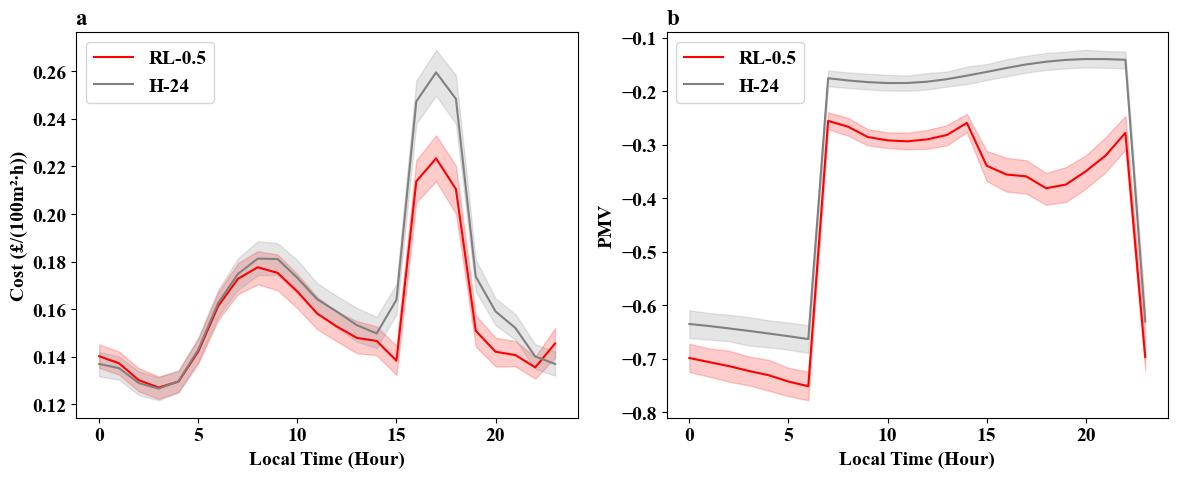

In [13]:
import seaborn as sns
rmodel = {'model': {'dqn0.3': 'RL-0.3', 'dqn0.5': 'RL-0.5', 'dqn0.7': 'RL-0.7',
            '18': 'H-18', '20': 'H-20', '22': 'H-22', '24': 'H-24'}}

diff_all = get_difference_full(urban_climate).sort_values(by='model').replace(rmodel)
urban_climate = urban_climate.replace(rmodel)
def plot_time_series(urb_climate, diff_all, model, var, ax, plot_urban_climate=False, color=None):
    urb_climate = urb_climate[urb_climate['hac_type'].str.contains('on_wasteheat')]
    _plot_urban_climate = urb_climate.query(f'model == "{model}"').sort_values(by='time')
    _plot_diff_all = diff_all.query(f'model == "{model}"').sort_values(by='time')
    
    _plot_urban_climate['hour'] = _plot_urban_climate['time'].dt.hour
    _plot_diff_all['hour'] = _plot_diff_all['time'].dt.hour
    if color is None:
        color = 'red' if 'H' not in model else 'gray'
    
    if plot_urban_climate:
        print(f"{model} - {var} - Urban Climate")
        display(_plot_urban_climate.groupby('hour')[var].mean().round(2).reset_index().T)
        #display(_plot_urban_climate.groupby('hour')[var].std().round(2).reset_index().T)
        print(f"max: {_plot_urban_climate.groupby('hour')[var].mean().round(2).max()}")
        print(f'min: {_plot_urban_climate.groupby('hour')[var].mean().round(2).min()}')
        sns.lineplot(data=_plot_urban_climate, x='hour', y=var, label=model, color=color, ax=ax)
    else:
        print(f"{model} - {var} - Difference")
        #display(_plot_diff_all.groupby('hour')[var].mean().round(4).reset_index().T)
        #display(_plot_diff_all.groupby('hour')[var].std().round(4).reset_index().T)
        print(f"max: {_plot_diff_all.groupby('hour')[var].mean().round(4).max()}")
        print(f"min: {_plot_diff_all.groupby('hour')[var].mean().round(4).min()}")
        sns.lineplot(data=_plot_diff_all, x='hour', y=var, label=model, color=color, ax=ax)
    ax.set_ylabel(var)
    ax.legend()
    
def plot_corr(ax, urb_climate, model):
    label = ['Cost', 'PMV', 'T', 'Price']
    corr = urban_climate.query('model == "RL-0.5"')[['cost', 'pmv', 'TSA', 'ele_price']].corr(method='spearman')
    sns.heatmap(corr.values[2:4, 0:2], annot=True, cmap='coolwarm', ax=ax, vmin=-1, vmax=1)
    ax.set_xticklabels(label[:2])
    ax.set_yticklabels(label[2:4])

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
axs = axs.flatten()

colors = sns.color_palette("YlGn", n_colors=3) + ['grey', 'black']
def plot_ax(ax, var):
    
    #plot_time_series(urban_climate, diff_all, 'RL-0.7', var, ax, plot_urban_climate=True, color=colors[0])
    plot_time_series(urban_climate, diff_all, 'RL-0.5', var, ax, plot_urban_climate=True, color='red')
    #plot_time_series(urban_climate, diff_all, 'RL-0.3', var, ax, plot_urban_climate=True, color=colors[2])
    #plot_time_series(urban_climate, diff_all, 'H-20', var, ax, plot_urban_climate=True, color=colors[3])
    #plot_time_series(urban_climate, diff_all, 'H-22', var, ax, plot_urban_climate=True, color=colors[3])
    plot_time_series(urban_climate, diff_all, 'H-24', var, ax, plot_urban_climate=True, color='grey')
plot_ax(axs[0], 'cost')
plot_ax(axs[1], 'pmv')
#plot_time_series(urban_climate, diff_all, 'RL-0.5', 'pmv', axs[1], plot_urban_climate=True, color=colors[1])
#plot_time_series(urban_climate, diff_all, 'H-24', 'pmv', axs[1], plot_urban_climate=True, color=colors[2])

for ax in axs:
    ax.set_xlabel('Local Time (Hour)')
    
for ax in [axs[0]]:
    ax.set_ylabel('Cost (£/(100m²·h))')

axs[1].set_ylabel('PMV')
titles = ['a', 'b']
for i, ax in enumerate(axs):
    ax.set_title(titles[i], loc='left', fontweight='bold')
#axs[3].set_ylabel('$\Delta$PMV')
#axs[1].set_xticklabels(Month_lable)
plt.tight_layout()
plt.savefig('figs/daily_profile_of_cost_pmv_r5.pdf', dpi=300)
plt.show()

RL-0.7 - cost - Urban Climate


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
hour,0.00,1.00,2.00,3.00,4.00,5.00,6.00,7.00,8.00,9.00,...,14.00,15.00,16.00,17.00,18.00,19.00,20.00,21.00,22.00,23.00
cost,0.14,0.14,0.13,0.12,0.12,0.13,0.15,0.16,0.17,0.16,...,0.13,0.14,0.21,0.22,0.22,0.17,0.15,0.14,0.14,0.14


max: 0.22
min: 0.12
RL-0.5 - cost - Urban Climate


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
hour,0.00,1.00,2.00,3.00,4.00,5.00,6.00,7.00,8.00,9.00,...,14.00,15.00,16.00,17.00,18.00,19.00,20.00,21.00,22.00,23.00
cost,0.14,0.14,0.13,0.13,0.13,0.14,0.16,0.17,0.18,0.18,...,0.15,0.14,0.21,0.22,0.21,0.15,0.14,0.14,0.14,0.15


max: 0.22
min: 0.13
RL-0.3 - cost - Urban Climate


...

max: -0.22
min: -0.73
H-20 - pmv - Urban Climate


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
hour,0.00,1.00,2.00,3.00,4.00,5.00,6.00,7.00,8.00,9.00,...,14.00,15.00,16.00,17.00,18.00,19.00,20.00,21.00,22.00,23.00
pmv,-1.45,-1.46,-1.46,-1.47,-1.47,-1.48,-1.48,-0.87,-0.88,-0.88,...,-0.87,-0.86,-0.85,-0.85,-0.84,-0.84,-0.84,-0.84,-0.84,-1.45


max: -0.84
min: -1.48
H-24 - pmv - Urban Climate


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
hour,0.00,1.00,2.00,3.00,4.00,5.00,6.00,7.00,8.00,9.00,...,14.00,15.00,16.00,17.00,18.00,19.00,20.00,21.00,22.00,23.00
pmv,-0.63,-0.64,-0.64,-0.65,-0.65,-0.66,-0.66,-0.18,-0.18,-0.18,...,-0.17,-0.16,-0.16,-0.15,-0.14,-0.14,-0.14,-0.14,-0.14,-0.63


max: -0.14
min: -0.66


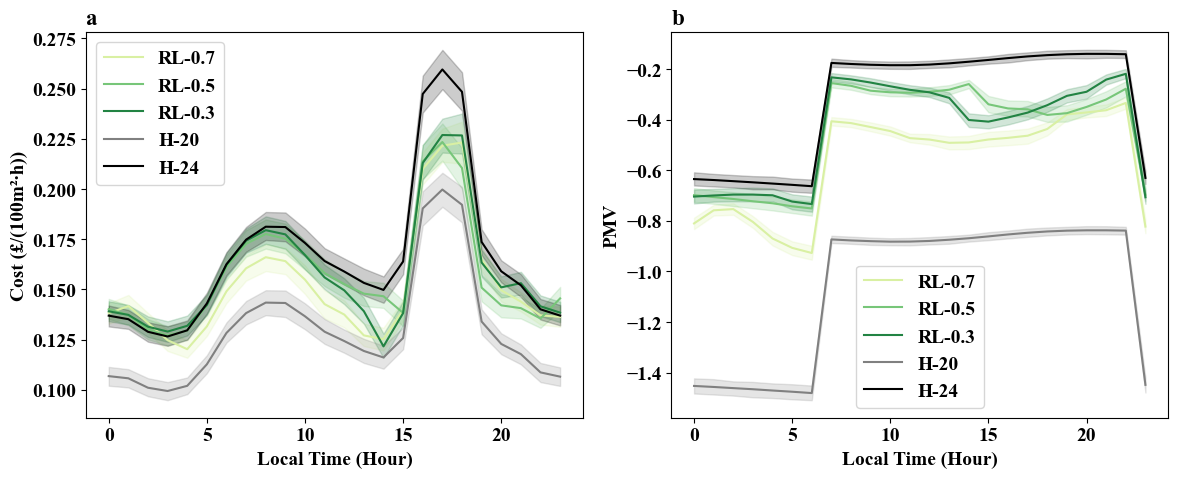

In [14]:
import seaborn as sns
rmodel = {'model': {'dqn0.3': 'RL-0.3', 'dqn0.5': 'RL-0.5', 'dqn0.7': 'RL-0.7',
            '18': 'H-18', '20': 'H-20', '22': 'H-22', '24': 'H-24'}}

diff_all = get_difference_full(urban_climate).sort_values(by='model').replace(rmodel)
urban_climate = urban_climate.replace(rmodel)
def plot_time_series(urb_climate, diff_all, model, var, ax, plot_urban_climate=False, color=None):
    urb_climate = urb_climate[urb_climate['hac_type'].str.contains('on_wasteheat')]
    _plot_urban_climate = urb_climate.query(f'model == "{model}"').sort_values(by='time')
    _plot_diff_all = diff_all.query(f'model == "{model}"').sort_values(by='time')
    
    _plot_urban_climate['hour'] = _plot_urban_climate['time'].dt.hour
    _plot_diff_all['hour'] = _plot_diff_all['time'].dt.hour
    if color is None:
        color = 'red' if 'H' not in model else 'gray'
    
    if plot_urban_climate:
        print(f"{model} - {var} - Urban Climate")
        display(_plot_urban_climate.groupby('hour')[var].mean().round(2).reset_index().T)
        #display(_plot_urban_climate.groupby('hour')[var].std().round(2).reset_index().T)
        print(f"max: {_plot_urban_climate.groupby('hour')[var].mean().round(2).max()}")
        print(f'min: {_plot_urban_climate.groupby('hour')[var].mean().round(2).min()}')
        sns.lineplot(data=_plot_urban_climate, x='hour', y=var, label=model, color=color, ax=ax)
    else:
        print(f"{model} - {var} - Difference")
        #display(_plot_diff_all.groupby('hour')[var].mean().round(4).reset_index().T)
        #display(_plot_diff_all.groupby('hour')[var].std().round(4).reset_index().T)
        print(f"max: {_plot_diff_all.groupby('hour')[var].mean().round(4).max()}")
        print(f"min: {_plot_diff_all.groupby('hour')[var].mean().round(4).min()}")
        sns.lineplot(data=_plot_diff_all, x='hour', y=var, label=model, color=color, ax=ax)
    ax.set_ylabel(var)
    ax.legend()
    
def plot_corr(ax, urb_climate, model):
    label = ['Cost', 'PMV', 'T', 'Price']
    corr = urban_climate.query('model == "RL-0.5"')[['cost', 'pmv', 'TSA', 'ele_price']].corr(method='spearman')
    sns.heatmap(corr.values[2:4, 0:2], annot=True, cmap='coolwarm', ax=ax, vmin=-1, vmax=1)
    ax.set_xticklabels(label[:2])
    ax.set_yticklabels(label[2:4])

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
axs = axs.flatten()

colors = sns.color_palette("YlGn", n_colors=3) + ['grey', 'black']
def plot_ax(ax, var):
    
    plot_time_series(urban_climate, diff_all, 'RL-0.7', var, ax, plot_urban_climate=True, color=colors[0])
    plot_time_series(urban_climate, diff_all, 'RL-0.5', var, ax, plot_urban_climate=True, color=colors[1])
    plot_time_series(urban_climate, diff_all, 'RL-0.3', var, ax, plot_urban_climate=True, color=colors[2])
    plot_time_series(urban_climate, diff_all, 'H-20', var, ax, plot_urban_climate=True, color=colors[3])
    #plot_time_series(urban_climate, diff_all, 'H-22', var, ax, plot_urban_climate=True, color=colors[3])
    plot_time_series(urban_climate, diff_all, 'H-24', var, ax, plot_urban_climate=True, color=colors[4])
plot_ax(axs[0], 'cost')
plot_ax(axs[1], 'pmv')
#plot_time_series(urban_climate, diff_all, 'RL-0.5', 'pmv', axs[1], plot_urban_climate=True, color=colors[1])
#plot_time_series(urban_climate, diff_all, 'H-24', 'pmv', axs[1], plot_urban_climate=True, color=colors[2])

for ax in axs:
    ax.set_xlabel('Local Time (Hour)')
    
for ax in [axs[0]]:
    ax.set_ylabel('Cost (£/(100m²·h))')

axs[1].set_ylabel('PMV')
titles = ['a', 'b']
for i, ax in enumerate(axs):
    ax.set_title(titles[i], loc='left', fontweight='bold')
#axs[3].set_ylabel('$\Delta$PMV')
#axs[1].set_xticklabels(Month_lable)
plt.tight_layout()
plt.savefig('figs/daily_profile_of_cost_pmv.pdf', dpi=300)
plt.show()

RL-0.5 - cost - Difference
mean: 0.005658333333333334
max: 0.0077
min: 0.0045
H-24 - cost - Difference
mean: 0.0051916666666666665
max: 0.0072
min: 0.0039
RL-0.5 - pmv - Difference
mean: -0.0183125
max: -0.0167
min: -0.0201
H-24 - pmv - Difference
mean: -0.019445833333333332
max: -0.0175
min: -0.0211


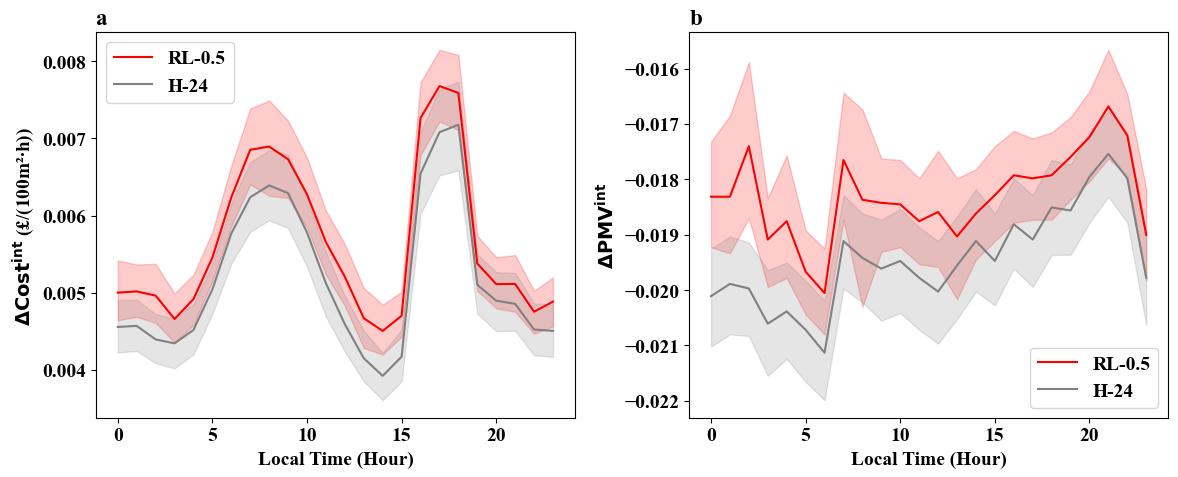

In [15]:
import seaborn as sns
rmodel = {'model': {'dqn0.3': 'RL-0.3', 'dqn0.5': 'RL-0.5', 'dqn0.7': 'RL-0.7',
            '18': 'H-18', '20': 'H-20', '22': 'H-22', '24': 'H-24'}}

diff_all = get_difference_full(urban_climate).sort_values(by='model').replace(rmodel)
urban_climate_2012 = urban_climate_2012.replace(rmodel)
urban_climate = urban_climate.replace(rmodel)
def plot_time_series(urb_climate, diff_all, model, var, ax, plot_urban_climate=False):
    urb_climate = urb_climate[urb_climate['hac_type'].str.contains('on_wasteheat')]
    _plot_urban_climate = urb_climate.query(f'model == "{model}"').sort_values(by='time')
    _plot_diff_all = diff_all.query(f'model == "{model}"').sort_values(by='time')
    
    _plot_urban_climate['hour'] = _plot_urban_climate['time'].dt.hour
    _plot_diff_all['hour'] = _plot_diff_all['time'].dt.hour
    color = 'red' if 'H' not in model else 'gray'
    
    if plot_urban_climate:
        print(f"{model} - {var} - Urban Climate")
        display(_plot_urban_climate.groupby('hour')[var].mean().round(2).reset_index().T)
        #display(_plot_urban_climate.groupby('hour')[var].std().round(2).reset_index().T)
        print(f"mean: {_plot_urban_climate.groupby('hour')[var].mean().round(2).mean()}")
        print(f"max: {_plot_urban_climate.groupby('hour')[var].mean().round(2).max()}")
        print(f'min: {_plot_urban_climate.groupby('hour')[var].mean().round(2).min()}')
        sns.lineplot(data=_plot_urban_climate, x='hour', y=var, label=model, color=color, alpha=0.5, ax=ax)
    else:
        print(f"{model} - {var} - Difference")
        #display(_plot_diff_all.groupby('hour')[var].mean().round(4).reset_index().T)
        #display(_plot_diff_all.groupby('hour')[var].std().round(4).reset_index().T)
        print(f"mean: {_plot_diff_all.groupby('hour')[var].mean().round(4).mean()}")
        print(f"max: {_plot_diff_all.groupby('hour')[var].mean().round(4).max()}")
        print(f"min: {_plot_diff_all.groupby('hour')[var].mean().round(4).min()}")
        sns.lineplot(data=_plot_diff_all, x='hour', y=var, label=model, color=color, ax=ax)
    ax.set_ylabel(var)
    ax.legend()
    
def plot_corr(ax, urb_climate, model):
    label = ['Cost', 'PMV', 'T', 'Price']
    corr = urban_climate.query('model == "RL-0.5"')[['cost', 'pmv', 'TSA', 'ele_price']].corr(method='spearman')
    sns.heatmap(corr.values[2:4, 0:2], annot=True, cmap='coolwarm', ax=ax, vmin=-1, vmax=1)
    ax.set_xticklabels(label[:2])
    ax.set_yticklabels(label[2:4])

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
axs = axs.flatten()

plot_time_series(urban_climate, diff_all, 'RL-0.5', 'cost', axs[0], plot_urban_climate=False)
plot_time_series(urban_climate, diff_all, 'H-24', 'cost', axs[0], plot_urban_climate=False)
plot_time_series(urban_climate, diff_all, 'RL-0.5', 'pmv', axs[1], plot_urban_climate=False)
plot_time_series(urban_climate, diff_all, 'H-24', 'pmv', axs[1], plot_urban_climate=False)

for ax in axs:
    ax.set_xlabel('Local Time (Hour)')
    
for ax in [axs[0]]:
    # $\Delta^{\mathrm{int}}$
    ax.set_ylabel('$\Delta \mathrm{Cost}^{\mathrm{int}}$ (£/(100m²·h))')

axs[1].set_ylabel('$\Delta \mathrm{PMV}^{\mathrm{int}}$')
titles = ['a', 'b']
for i, ax in enumerate(axs):
    ax.set_title(titles[i], loc='left', fontweight='bold')
#axs[3].set_ylabel('$\Delta$PMV')
#axs[1].set_xticklabels(Month_lable)
plt.tight_layout()
plt.savefig('figs/daily_profile_of_cost_pmv_diff.pdf', dpi=300)
plt.show()

In [16]:
urban_climate

,time,TSA,TBUILD,URBAN_HEAT,RH2M,cost,ele_price,benefit,pmv,model,hac_type,COP
0,2012-11-01 00:00:00,284.79175,293.15,16.838844,76.041240,0.046775,11.15275,-1.2769,-1.63,RL-0.3,on_wasteheat,4.014923
1,2012-11-01 00:30:00,284.92303,297.15,39.636894,75.239720,0.127556,12.95000,-0.2809,-1.03,RL-0.3,on_wasteheat,4.024112
2,2012-11-01 01:00:00,285.07315,297.15,30.362326,74.793480,0.086063,11.43625,-0.2500,-1.00,RL-0.3,on_wasteheat,4.034621
3,2012-11-01 01:30:00,284.84976,297.15,29.905626,77.361650,0.061815,8.30725,-0.2401,-0.99,RL-0.3,on_wasteheat,4.018983
4,2012-11-01 02:00:00,283.24600,297.15,30.363676,81.780910,0.065055,8.37025,-0.2209,-0.97,RL-0.3,on_wasteheat,3.906720
...,...,...,...,...,...,...,...,...,...,...,...,...
130315,2013-04-30 21:30:00,282.54865,297.15,18.960570,63.074097,0.065336,13.10050,0.0000,0.16,H-24,on_24,3.857906
130316,2013-04-30 22:00:00,282.16330,297.15,19.315937,63.535725,0.071811,14.04200,0.0000,0.16,H-24,on_24,3.830931
130317,2013-04-30 22:30:00,281.70743,297.15,19.739899,63.132110,0.065888,12.50900,0.0000,0.15,H-24,on_24,3.799020
130318,2013-04-30 23:00:00,281.41520,297.15,20.100847,63.043570,0.070730,13.12150,-0.0016,-0.54,H-24,on_24,3.778564


length of merged DataFrame: 8688 8688 8688
RL-0.5 - cost - Percentage Difference


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
hour,0.000,1.000,2.000,3.0000,4.0000,5.0000,6.0000,7.0000,8.0000,9.0000,...,14.0000,15.0000,16.0000,17.0000,18.0000,19.0000,20.0000,21.0000,22.0000,23.0000
cost_diff,0.005,0.005,0.005,0.0047,0.0049,0.0055,0.0062,0.0069,0.0069,0.0067,...,0.0045,0.0047,0.0073,0.0077,0.0076,0.0054,0.0051,0.0051,0.0048,0.0049


max: 4.4099
min: 2.9453
mean: 3.6042
length of merged DataFrame: 8688 8688 8688
H-24 - cost - Percentage Difference


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
hour,0.0000,1.0000,2.0000,3.0000,4.0000,5.000,6.0000,7.0000,8.0000,9.0000,...,14.0000,15.0000,16.0000,17.0000,18.0000,19.0000,20.0000,21.0000,22.0000,23.0000
cost_diff,0.0046,0.0046,0.0044,0.0043,0.0045,0.005,0.0058,0.0062,0.0064,0.0063,...,0.0039,0.0042,0.0065,0.0071,0.0072,0.0051,0.0049,0.0049,0.0045,0.0045


max: 3.394
min: 2.3781
mean: 2.9571


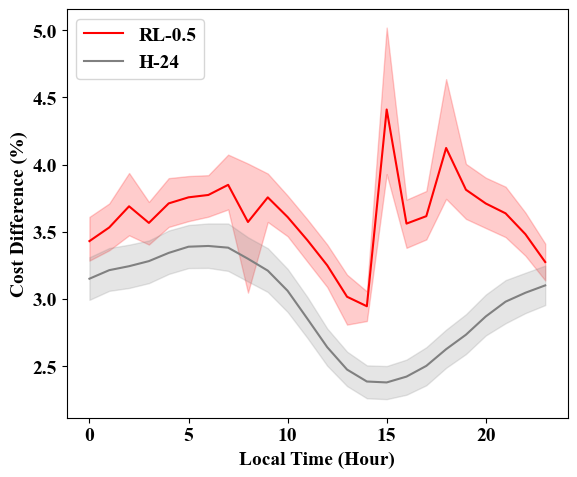

In [17]:
import seaborn as sns
rmodel = {'model': {'dqn0.3': 'RL-0.3', 'dqn0.5': 'RL-0.5', 'dqn0.7': 'RL-0.7',
            '18': 'H-18', '20': 'H-20', '22': 'H-22', '24': 'H-24'}}

diff_all = get_difference_full(urban_climate).sort_values(by='model').replace(rmodel)
urban_climate_2012 = urban_climate_2012.replace(rmodel)
urban_climate = urban_climate.replace(rmodel)
def plot_time_series(urb_climate, diff_all, model, var, ax, plot_pct=False):
    urb_climate = urb_climate[urb_climate['hac_type'].str.contains('on_wasteheat')]
    _plot_urban_climate = urb_climate.query(f'model == "{model}"').sort_values(by='time')
    _plot_diff_all = diff_all.query(f'model == "{model}"').sort_values(by='time')
    
    _plot_urban_climate['hour'] = _plot_urban_climate['time'].dt.hour
    _plot_diff_all['hour'] = _plot_diff_all['time'].dt.hour
    color = 'red' if 'H' not in model else 'gray'
    
    if plot_pct:
        _plot_pct_dff = pd.merge(_plot_urban_climate[['time', var]], 
                                 _plot_diff_all[['time', var]], 
                                 on=['time'], suffixes=('_urban', '_diff'))
        print('length of merged DataFrame:', len(_plot_urban_climate), len(_plot_diff_all), len(_plot_pct_dff))
        assert len(_plot_pct_dff) == len(_plot_urban_climate) == len(_plot_diff_all), "Merged DataFrame length mismatch. Check the merge keys and data integrity."
        _plot_pct_dff['diff'] = _plot_pct_dff[f'{var}_diff'] / _plot_pct_dff[f'{var}_urban'] * 100
        #assert not _plot_pct_dff['diff'].isna().any(), "Percentage difference contains NaN values. Check for division by zero."
        _plot_pct_dff['hour'] = _plot_pct_dff['time'].dt.hour
        print(f"{model} - {var} - Percentage Difference")
        display(_plot_pct_dff.groupby('hour')[f'{var}_diff'].mean().round(4).reset_index().T)
        #display(_plot_pct_dff.groupby('hour')[f'{var}_diff'].std().round(4).reset_index().T)
        print(f"max: {_plot_pct_dff.groupby('hour')[f'diff'].mean().round(4).max()}")
        print(f"min: {_plot_pct_dff.groupby('hour')[f'diff'].mean().round(4).min()}")
        print(f"mean: {_plot_pct_dff[f'diff'].mean().round(4)}")
        sns.lineplot(data=_plot_pct_dff, x='hour', y='diff', label=model, color=color, ax=ax)
    else:
        print(f"{model} - {var} - Difference")
        #display(_plot_diff_all.groupby('hour')[var].mean().round(4).reset_index().T)
        #display(_plot_diff_all.groupby('hour')[var].std().round(4).reset_index().T)
        print(f"max: {_plot_diff_all.groupby('hour')[var].mean().round(4).max()}")
        print(f"min: {_plot_diff_all.groupby('hour')[var].mean().round(4).min()}")
        sns.lineplot(data=_plot_diff_all, x='hour', y=var, label=model, color=color, ax=ax)
    ax.set_ylabel(var)
    ax.legend()
    
def plot_corr(ax, urb_climate, model):
    label = ['Cost', 'PMV', 'T', 'Price']
    corr = urban_climate.query('model == "RL-0.5"')[['cost', 'pmv', 'TSA', 'ele_price']].corr(method='spearman')
    sns.heatmap(corr.values[2:4, 0:2], annot=True, cmap='coolwarm', ax=ax, vmin=-1, vmax=1)
    ax.set_xticklabels(label[:2])
    ax.set_yticklabels(label[2:4])

fig, axs = plt.subplots(1, figsize=(6, 5))
plot_time_series(urban_climate, diff_all, 'RL-0.5', 'cost', axs, plot_pct=True)
plot_time_series(urban_climate, diff_all, 'H-24', 'cost', axs, plot_pct=True)


#for ax in axs[2:]:
#    ax.set_xlabel('Local Time (Hour)')
#
#ylabes = ['$\Delta$ Cost (£/(100m²·h))', '$\Delta$ PMV', '$\Delta$ Cost (%)', '$\Delta$ PMV (%)']
#for i, ax in enumerate(axs):
#    ax.set_ylabel(ylabes[i])
#
#titles = ['a', 'b', 'c', 'd']
#for i, ax in enumerate(axs):
#    ax.set_title(titles[i], loc='left', fontweight='bold')
axs.set_xlabel('Local Time (Hour)')
axs.set_ylabel('Cost Difference (%)')
#axs[1].set_xticklabels(Month_lable)
plt.tight_layout()
#plt.savefig('figs/urb_climate_difference_density_london_2012.pdf', dpi=300)
plt.show()

In [18]:
urban_climate

,time,TSA,TBUILD,URBAN_HEAT,RH2M,cost,ele_price,benefit,pmv,model,hac_type,COP
0,2012-11-01 00:00:00,284.79175,293.15,16.838844,76.041240,0.046775,11.15275,-1.2769,-1.63,RL-0.3,on_wasteheat,4.014923
1,2012-11-01 00:30:00,284.92303,297.15,39.636894,75.239720,0.127556,12.95000,-0.2809,-1.03,RL-0.3,on_wasteheat,4.024112
2,2012-11-01 01:00:00,285.07315,297.15,30.362326,74.793480,0.086063,11.43625,-0.2500,-1.00,RL-0.3,on_wasteheat,4.034621
3,2012-11-01 01:30:00,284.84976,297.15,29.905626,77.361650,0.061815,8.30725,-0.2401,-0.99,RL-0.3,on_wasteheat,4.018983
4,2012-11-01 02:00:00,283.24600,297.15,30.363676,81.780910,0.065055,8.37025,-0.2209,-0.97,RL-0.3,on_wasteheat,3.906720
...,...,...,...,...,...,...,...,...,...,...,...,...
130315,2013-04-30 21:30:00,282.54865,297.15,18.960570,63.074097,0.065336,13.10050,0.0000,0.16,H-24,on_24,3.857906
130316,2013-04-30 22:00:00,282.16330,297.15,19.315937,63.535725,0.071811,14.04200,0.0000,0.16,H-24,on_24,3.830931
130317,2013-04-30 22:30:00,281.70743,297.15,19.739899,63.132110,0.065888,12.50900,0.0000,0.15,H-24,on_24,3.799020
130318,2013-04-30 23:00:00,281.41520,297.15,20.100847,63.043570,0.070730,13.12150,-0.0016,-0.54,H-24,on_24,3.778564


In [19]:
diff_all

,time,model,TSA,TBUILD,URBAN_HEAT,RH2M,cost,ele_price,benefit,pmv,COP
34752,2012-11-01 00:00:00,H-18,-0.17948,0.0,0.489057,0.889450,0.001470,0.0,-0.0620,-0.02,-0.012564
37640,2012-12-31 04:00:00,H-18,-0.31113,0.0,0.647642,1.938360,0.001151,0.0,-0.0193,-0.01,-0.021779
37641,2012-12-31 04:30:00,H-18,-0.26742,0.0,0.623939,1.668715,0.001022,0.0,-0.0384,-0.02,-0.018719
37642,2012-12-31 05:00:00,H-18,-0.30588,0.0,0.645734,1.977240,0.001045,0.0,-0.0384,-0.02,-0.021412
37643,2012-12-31 05:30:00,H-18,-0.28920,0.0,0.636789,1.861380,0.001420,0.0,-0.0191,-0.01,-0.020244
...,...,...,...,...,...,...,...,...,...,...,...
20264,2012-12-31 04:00:00,RL-0.7,-0.41356,0.0,0.817871,2.432230,0.001576,0.0,-0.0024,-0.02,-0.028949
20263,2012-12-31 03:30:00,RL-0.7,-0.50550,0.0,0.864548,3.041516,0.001660,0.0,-0.0028,-0.02,-0.035385
20262,2012-12-31 03:00:00,RL-0.7,-0.45218,0.0,0.831692,2.689860,0.002011,0.0,-0.0028,-0.02,-0.031653
20276,2012-12-31 10:00:00,RL-0.7,-0.16807,0.0,0.667342,0.955190,0.003660,0.0,-0.0008,-0.02,-0.011765


cost mean 0.15694602062180896
pmv mean -0.44725023020257826


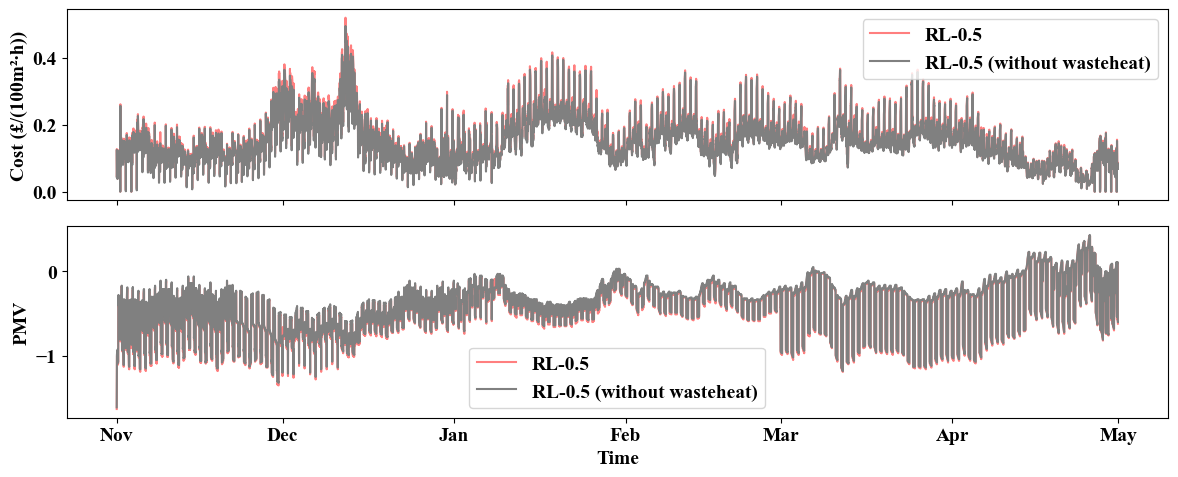

In [20]:
import seaborn as sns
rmodel = {'model': {'dqn0.3': 'RL-0.3', 'dqn0.5': 'RL-0.5', 'dqn0.7': 'RL-0.7',
            '18': 'H-18', '20': 'H-20', '22': 'H-22', '24': 'H-24'}}

diff_all = get_difference_full(urban_climate).sort_values(by='model').replace(rmodel)
urban_climate_2012 = urban_climate_2012.replace(rmodel)
urban_climate = urban_climate.replace(rmodel)
def plot_time_series(urb_climate, diff_all, model, var, ax):
    urb_climate2 = urb_climate.copy()
    urb_climate = urb_climate[urb_climate['hac_type'].str.contains('on_wasteheat')]
    _plot_urban_climate = urb_climate.query(f'model == "{model}"').sort_values(by='time')
    
    #if var == 'pmv':
    #    _plot_urban_climate = _plot_urban_climate[['time', var, 'cost']].resample('1D', on='time').mean().reset_index()
    #else:
    #    _plot_urban_climate = _plot_urban_climate[['time', var, 'cost']].resample('1D', on='time').mean().reset_index()
    _plot_diff_all = diff_all.query(f'model == "{model}"').sort_values(by='time')
    #_plot_diff_all = _plot_diff_all[['time', var]].resample('1D', on='time').mean().reset_index()
    #display(_plot_urban_climate.head())
    #ax.plot(_plot_urban_climate['time'], _plot_urban_climate[var], label='Urban Climate', color='gray', alpha=0.5)
    # right y-axis for difference
    #
    color = 'red' if 'H' not in model else 'gray'
    print(f'{var} mean', _plot_urban_climate[var].mean())
    ax.plot(_plot_urban_climate['time'], _plot_urban_climate[var], label=model, color=color, alpha=0.5)#color='red', alpha=0.5)
    
    urb_climate = urb_climate2[~urb_climate2['hac_type'].str.contains('on_wasteheat')]
    _plot_urban_climate = urb_climate.query(f'model == "{model}"').sort_values(by='time')
    ax.plot(_plot_urban_climate['time'], _plot_urban_climate[var], label=model+' (without wasteheat)', color='gray', alpha=1)#color='red', alpha=0.5)
    #ax.set_title(f'{model}', fontsize=14, fontweight='normal', loc='left')
    #ax2 = ax.twinx()
    #ax2.plot(_plot_urban_climate['time'], _plot_urban_climate[var], label='Urban Climate', color='gray', alpha=0.2)
    #ax2.set_ylim(0, 45)
    ax.set_ylabel(var)
    ax.legend()
    
def plot_corr(ax, urb_climate, model):
    label = ['Cost', 'PMV', 'T', 'Price']
    corr = urban_climate.query('model == "RL-0.5"')[['cost', 'pmv', 'TSA', 'ele_price']].corr(method='spearman')
    sns.heatmap(corr.values[2:4, 0:2], annot=True, cmap='coolwarm', ax=ax, vmin=-1, vmax=1)
    ax.set_xticklabels(label[:2])
    ax.set_yticklabels(label[2:4])

fig, axs = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
#plot_time_series(urban_climate_2012, diff_all, 'H-24', 'TSA', axs[0])
#plot_time_series(urban_climate_2012, diff_all, 'RL-0.3', 'cost', axs[0])
#plot_time_series(urban_climate_2012, diff_all, 'RL-0.5', 'cost', axs[0])
plot_time_series(urban_climate, diff_all, 'RL-0.5', 'cost', axs[0])
#plot_time_series(urban_climate, diff_all, 'H-20', 'cost', axs[0])
#plot_time_series(urban_climate, diff_all, 'H-24', 'cost', axs[0])
#plot_time_series(urban_climate, diff_all, 'H-18', 'cost', axs[0])

# 插入子图
#inset_ax = fig.add_axes([0.85, 0.75, 0.1, 0.2])  # [left, bottom, width, height]
#plot_corr(inset_ax, urban_climate, 'RL-0.5')

plot_time_series(urban_climate, diff_all, 'RL-0.5', 'pmv', axs[1])
#plot_time_series(urban_climate, diff_all, 'H-20', 'pmv', axs[1])
#plot_time_series(urban_climate, diff_all, 'H-20', 'pmv', axs[1])
#plot_time_series(urban_climate, diff_all, 'H-24', 'pmv', axs[1])
#insert_ax = fig.add_axes([0.85, 0.21, 0.1, 0.2])  # [left, bottom, width, height]
#plot_corr(insert_ax, urban_climate, 'H-24')
Month = pd.to_datetime(urban_climate['time']).dt.month
Month_lable = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct']
axs[0].set_ylabel('Cost (£/(100m²·h))')
axs[1].set_ylabel('PMV')
axs[1].set_xlabel('Time')
axs[1].set_xticklabels(Month_lable)
plt.tight_layout()
#plt.savefig('figs/urb_climate_difference_density_london_2012.pdf', dpi=300)
plt.show()

Text(0.5, 1.0, 'H-24')

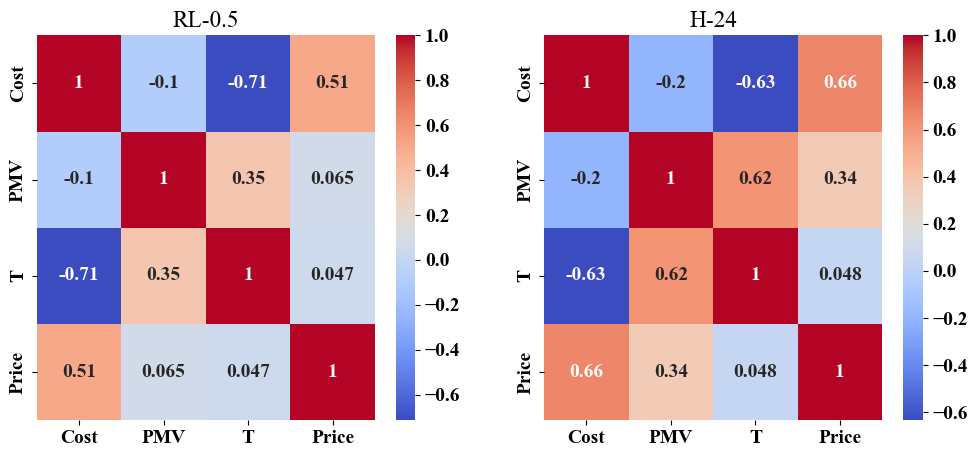

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
label = ['Cost', 'PMV', 'T', 'Price']
corr = urban_climate.query('model == "RL-0.5"')[['cost', 'pmv', 'TSA', 'ele_price']].corr(method='spearman')
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axs[0])
axs[0].set_title('RL-0.5')
axs[0].set_xticklabels(label)
axs[0].set_yticklabels(label)
corr = urban_climate.query('model == "H-24"')[['cost', 'pmv', 'TSA', 'ele_price']].corr(method='spearman')
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axs[1])
axs[1].set_xticklabels(label)
axs[1].set_yticklabels(label)
axs[1].set_title('H-24')

[Text(0, 0.5, 'T'), Text(0, 1.5, 'Price')]

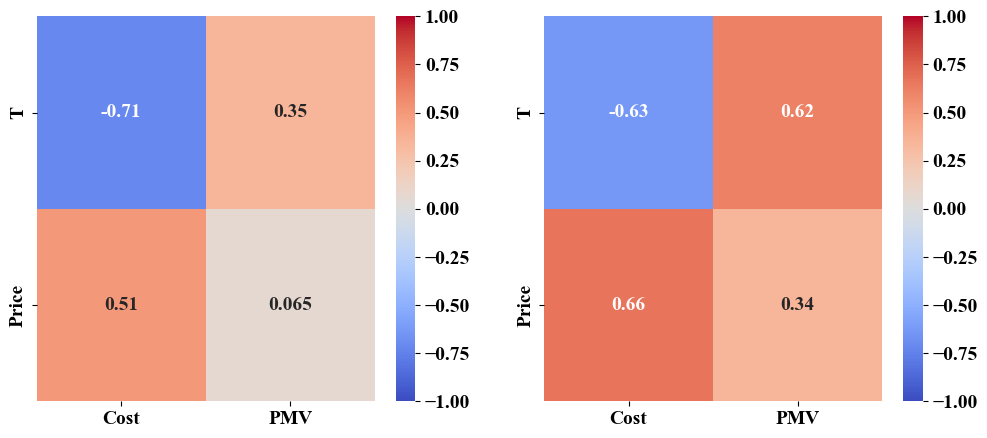

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
label = ['Cost', 'PMV', 'T', 'Price']
corr = urban_climate.query('model == "RL-0.5"')[['cost', 'pmv', 'TSA', 'ele_price']].corr(method='spearman')
sns.heatmap(corr.values[2:4, 0:2], annot=True, cmap='coolwarm', ax=axs[0], vmin=-1, vmax=1)
axs[0].set_xticklabels(label[:2])
axs[0].set_yticklabels(label[2:4])
corr = urban_climate.query('model == "H-24"')[['cost', 'pmv', 'TSA', 'ele_price']].corr(method='spearman')
sns.heatmap(corr.values[2:4, 0:2], annot=True, cmap='coolwarm', ax=axs[1], vmin=-1, vmax=1)
axs[1].set_xticklabels(label[:2])
axs[1].set_yticklabels(label[2:4])

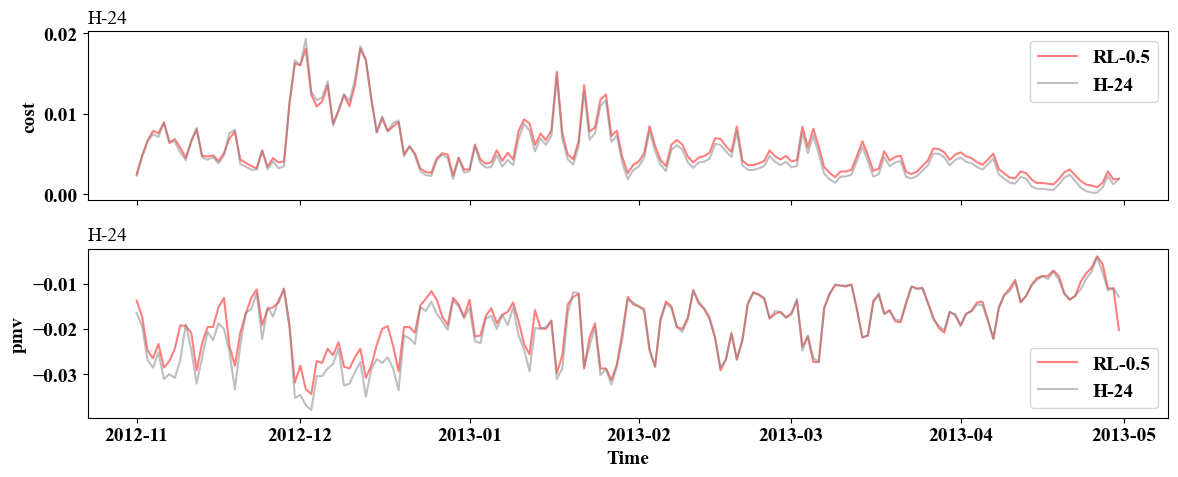

In [23]:
import seaborn as sns
rmodel = {'model': {'dqn0.3': 'RL-0.3', 'dqn0.5': 'RL-0.5', 'dqn0.7': 'RL-0.7',
            '18': 'H-18', '20': 'H-20', '22': 'H-22', '24': 'H-24'}}

diff_all = get_difference_full(urban_climate).sort_values(by='model').replace(rmodel)
urban_climate_2012 = urban_climate_2012.replace(rmodel)
def plot_time_series(urb_climate, diff_all, model, var, ax):
    urb_climate = urb_climate.copy()
    urb_climate = urb_climate[urb_climate['hac_type'].str.contains('on_wasteheat')]
    _plot_urban_climate = urb_climate.query(f'model == "{model}"').sort_values(by='time')
    _plot_urban_climate = _plot_urban_climate[['time', var]].resample('1D', on='time').mean().reset_index()
    _plot_diff_all = diff_all.query(f'model == "{model}"').sort_values(by='time')
    _plot_diff_all = _plot_diff_all[['time', var]].resample('1D', on='time').mean().reset_index()
    
    color = 'red' if 'H' not in model else 'gray'
    ax.plot(_plot_diff_all['time'], _plot_diff_all[var], label=model, color=color, alpha=0.5)#color='red', alpha=0.5)
    ax.set_title(f'{model}', fontsize=14, fontweight='normal', loc='left')
    #ax2 = ax.twinx()
    #ax2.plot(_plot_urban_climate['time'], _plot_urban_climate[var], label='Urban Climate', color='gray', alpha=0.2)
    #ax2.set_ylim(0, 45)
    ax.set_ylabel(var)
    ax.legend()

fig, axs = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
#plot_time_series(urban_climate_2012, diff_all, 'H-24', 'TSA', axs[0])
#plot_time_series(urban_climate_2012, diff_all, 'RL-0.3', 'cost', axs[0])
#plot_time_series(urban_climate_2012, diff_all, 'RL-0.5', 'cost', axs[0])
plot_time_series(urban_climate, diff_all, 'RL-0.5', 'cost', axs[0])
plot_time_series(urban_climate, diff_all, 'H-24', 'cost', axs[0])
#plot_time_series(urban_climate, diff_all, 'H-22', 'cost', axs[0])
#plot_time_series(urban_climate, diff_all, 'H-18', 'cost', axs[0])

plot_time_series(urban_climate, diff_all, 'RL-0.5', 'pmv', axs[1])
plot_time_series(urban_climate, diff_all, 'H-24', 'pmv', axs[1])
#plot_time_series(urban_climate, diff_all, 'H-22', 'pmv', axs[1])
#plot_time_series(urban_climate, diff_all, 'H-18', 'pmv', axs[1])

axs[1].set_xlabel('Time')
plt.tight_layout()
#plt.savefig('figs/urb_climate_difference_density_london_2012.pdf', dpi=300)
plt.show()

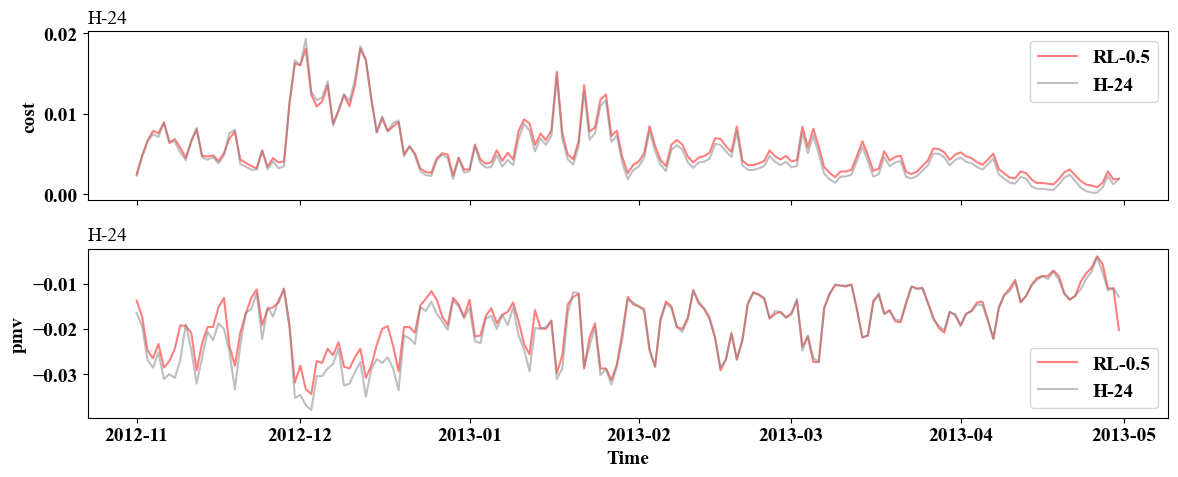

In [24]:
import seaborn as sns
rmodel = {'model': {'dqn0.3': 'RL-0.3', 'dqn0.5': 'RL-0.5', 'dqn0.7': 'RL-0.7',
            '18': 'H-18', '20': 'H-20', '22': 'H-22', '24': 'H-24'}}

diff_all = get_difference_full(urban_climate).sort_values(by='model').replace(rmodel)
urban_climate_2012 = urban_climate_2012.replace(rmodel)
def plot_time_series(urb_climate, diff_all, model, var, ax):
    urb_climate = urb_climate.copy()
    urb_climate = urb_climate[urb_climate['hac_type'].str.contains('on_wasteheat')]
    _plot_urban_climate = urb_climate.query(f'model == "{model}"').sort_values(by='time')
    _plot_urban_climate = _plot_urban_climate[['time', var]].resample('1D', on='time').mean().reset_index()
    _plot_diff_all = diff_all.query(f'model == "{model}"').sort_values(by='time')
    _plot_diff_all = _plot_diff_all[['time', var]].resample('1D', on='time').mean().reset_index()
    
    color = 'red' if 'H' not in model else 'gray'
    ax.plot(_plot_diff_all['time'], _plot_diff_all[var], label=model, color=color, alpha=0.5)#color='red', alpha=0.5)
    ax.set_title(f'{model}', fontsize=14, fontweight='normal', loc='left')
    #ax2 = ax.twinx()
    #ax2.plot(_plot_urban_climate['time'], _plot_urban_climate[var], label='Urban Climate', color='gray', alpha=0.2)
    #ax2.set_ylim(0, 45)
    ax.set_ylabel(var)
    ax.legend()

fig, axs = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
#plot_time_series(urban_climate_2012, diff_all, 'H-24', 'TSA', axs[0])
#plot_time_series(urban_climate_2012, diff_all, 'RL-0.3', 'cost', axs[0])
#plot_time_series(urban_climate_2012, diff_all, 'RL-0.5', 'cost', axs[0])
plot_time_series(urban_climate, diff_all, 'RL-0.5', 'cost', axs[0])
plot_time_series(urban_climate, diff_all, 'H-24', 'cost', axs[0])
#plot_time_series(urban_climate, diff_all, 'H-22', 'cost', axs[0])
#plot_time_series(urban_climate, diff_all, 'H-18', 'cost', axs[0])

plot_time_series(urban_climate, diff_all, 'RL-0.5', 'pmv', axs[1])
plot_time_series(urban_climate, diff_all, 'H-24', 'pmv', axs[1])
#plot_time_series(urban_climate, diff_all, 'H-22', 'pmv', axs[1])
#plot_time_series(urban_climate, diff_all, 'H-18', 'pmv', axs[1])

axs[1].set_xlabel('Time')
plt.tight_layout()
#plt.savefig('figs/urb_climate_difference_density_london_2012.pdf', dpi=300)
plt.show()

shape (181,) (181,)
mean RL-0.5 TSA -0.4110625402854513
shape (181,) (181,)
mean H-24 TSA -0.4295469854972377
shape (181,) (181,)
mean RL-0.5 RH2M 1.804382318945672
shape (181,) (181,)
mean H-24 RH2M 1.9635860271639043


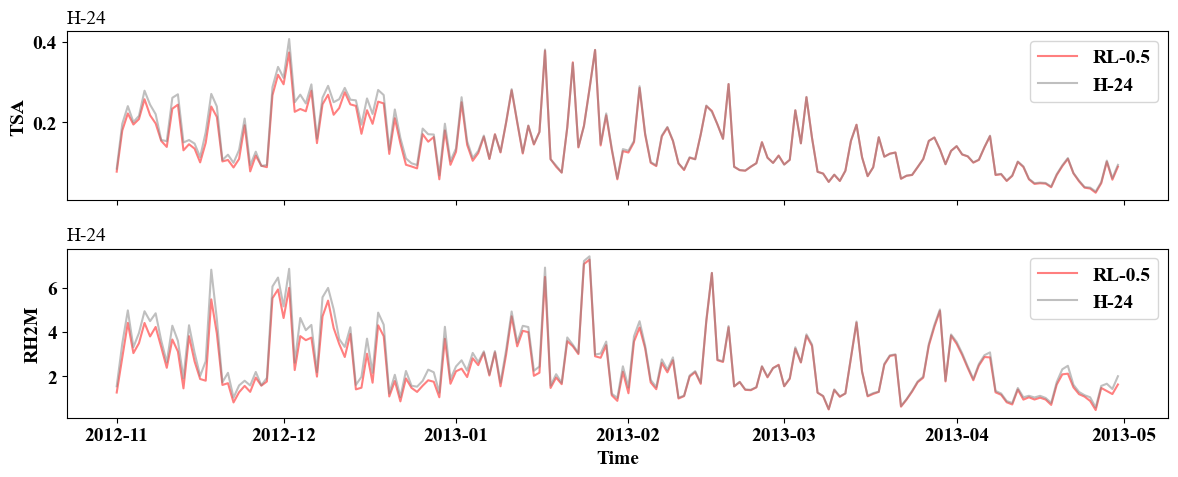

In [25]:
import seaborn as sns
rmodel = {'model': {'dqn0.3': 'RL-0.3', 'dqn0.5': 'RL-0.5', 'dqn0.7': 'RL-0.7',
            '18': 'H-18', '20': 'H-20', '22': 'H-22', '24': 'H-24'}}

diff_all = get_difference_full(urban_climate).sort_values(by='model').replace(rmodel)
urban_climate_2012 = urban_climate_2012.replace(rmodel)
def plot_time_series(urb_climate, diff_all, model, var, ax):
    urb_climate = urb_climate.copy()
    urb_climate = urb_climate[urb_climate['hac_type'].str.contains('on_wasteheat')]
    _plot_urban_climate = urb_climate.query(f'model == "{model}"').sort_values(by='time')
    _plot_urban_climate = _plot_urban_climate[['time', var]].resample('1D', on='time').mean().reset_index()
    _plot_diff_all = diff_all.query(f'model == "{model}"').sort_values(by='time')
    _plot_diff_all = _plot_diff_all[['time', var]].resample('1D', on='time').mean().reset_index()
    
    _plot_diff_all = _plot_diff_all.merge(_plot_urban_climate[['time', var]], on='time', suffixes=('_P', '_T'))
    
    print('shape', _plot_diff_all[f'{var}_P'].values.shape, _plot_diff_all[f'{var}_T'].values.shape)
    _plot_diff_all['diff'] = abs(_plot_diff_all[f'{var}_P'].values) / abs(_plot_diff_all[f'{var}_T'].values) * 100
    print(f'mean {model} {var}', _plot_diff_all[f'{var}_P'].mean())
    #ax.plot(_plot_urban_climate['time'], _plot_urban_climate[var], label='Urban Climate', color='gray', alpha=0.5)
    # right y-axis for difference
    #
    color = 'red' if 'H' not in model else 'gray'
    ax.plot(_plot_diff_all['time'], _plot_diff_all['diff'], label=model, color=color, alpha=0.5)#color='red', alpha=0.5)
    ax.set_title(f'{model}', fontsize=14, fontweight='normal', loc='left')
    #ax2 = ax.twinx()
    #ax2.plot(_plot_urban_climate['time'], _plot_urban_climate[var], label='Urban Climate', color='gray', alpha=0.2)
    #ax2.set_ylim(0, 45)
    ax.set_ylabel(var)
    ax.legend()

fig, axs = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
#plot_time_series(urban_climate_2012, diff_all, 'H-24', 'TSA', axs[0])
#plot_time_series(urban_climate_2012, diff_all, 'RL-0.3', 'cost', axs[0])
#plot_time_series(urban_climate_2012, diff_all, 'RL-0.5', 'cost', axs[0])
plot_time_series(urban_climate, diff_all, 'RL-0.5', 'TSA', axs[0])
plot_time_series(urban_climate, diff_all, 'H-24', 'TSA', axs[0])
#plot_time_series(urban_climate, diff_all, 'H-22', 'TSA', axs[0])
#plot_time_series(urban_climate, diff_all, 'H-18', 'TSA', axs[0])

plot_time_series(urban_climate, diff_all, 'RL-0.5', 'RH2M', axs[1])
plot_time_series(urban_climate, diff_all, 'H-24', 'RH2M', axs[1])
#plot_time_series(urban_climate, diff_all, 'H-22', 'RH2M', axs[1])
#plot_time_series(urban_climate, diff_all, 'H-18', 'RH2M', axs[1])

axs[1].set_xlabel('Time')
plt.tight_layout()
#plt.savefig('figs/urb_climate_difference_density_london_2012.pdf', dpi=300)
plt.show()

In [26]:
urban_climate['hac_type'].unique()

array(['on_wasteheat', 'on', 'off', 'on_wasteheat_20', 'on_20',
       'on_wasteheat_18', 'on_18', 'on_wasteheat_22', 'on_22',
       'on_wasteheat_24', 'on_24'], dtype=object)

RL-0.5 - TSA - Difference
mean: -0.4111
H-24 - TSA - Difference
mean: -0.4295
RL-0.5 - RH2M - Difference
mean: 1.8044
H-24 - RH2M - Difference
mean: 1.9636


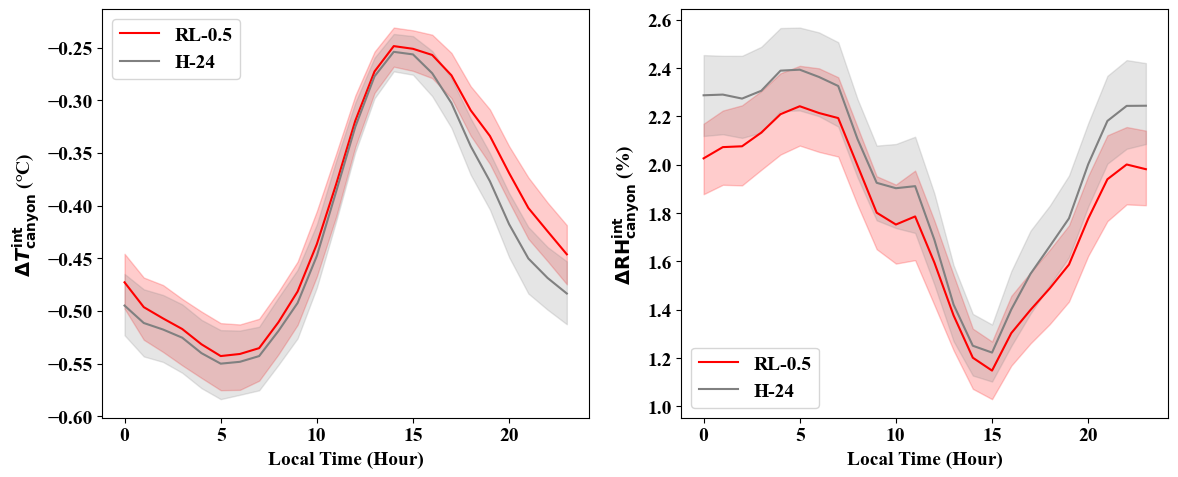

In [27]:
import seaborn as sns
rmodel = {'model': {'dqn0.3': 'RL-0.3', 'dqn0.5': 'RL-0.5', 'dqn0.7': 'RL-0.7',
            '18': 'H-18', '20': 'H-20', '22': 'H-22', '24': 'H-24'}}

diff_all = get_difference_full(urban_climate).sort_values(by='model').replace(rmodel)
urban_climate_2012 = urban_climate_2012.replace(rmodel)
def plot_time_series(urb_climate, diff_all, model, var, ax, plot_urban_climate=False):
    urb_climate = urb_climate[urb_climate['hac_type'].str.contains('on_wasteheat')]
    _plot_urban_climate = urb_climate.query(f'model == "{model}"').sort_values(by='time')
    _plot_diff_all = diff_all.query(f'model == "{model}"').sort_values(by='time')
    
    if plot_urban_climate:
        print(f"{model} - {var} - Urban Climate")
        print(f"mean: {_plot_urban_climate[var].mean()}")
    else:
        print(f"{model} - {var} - Difference")
        print(f"mean: {_plot_diff_all[var].mean().round(4)}")
    _plot_urban_climate['hour'] = _plot_urban_climate['time'].dt.hour
    _plot_diff_all['hour'] = _plot_diff_all['time'].dt.hour
    color = 'red' if 'H' not in model else 'gray'
    if plot_urban_climate:
        if var == 'TSA':
            _plot_urban_climate['TSA'] = _plot_urban_climate['TSA'] - 273.15
        sns.lineplot(data=_plot_urban_climate, x='hour', y=var, color=color, label=model, ax=ax)
    else:
        sns.lineplot(data=_plot_diff_all, x='hour', y=var, label=model, color=color, ax=ax)
    ax.set_ylabel(var)
    ax.legend()

#fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
#axs = axs.flatten()

#plot_time_series(urban_climate, diff_all, 'RL-0.5', 'TSA', axs[0], plot_urban_climate=True)
#plot_time_series(urban_climate, diff_all, 'H-24', 'TSA', axs[0], plot_urban_climate=True)
#
#plot_time_series(urban_climate, diff_all, 'RL-0.5', 'RH2M', axs[1], plot_urban_climate=True)
#plot_time_series(urban_climate, diff_all, 'H-24', 'RH2M', axs[1], plot_urban_climate=True)
#
#plot_time_series(urban_climate, diff_all, 'RL-0.5', 'TSA', axs[2], plot_urban_climate=False)
#plot_time_series(urban_climate, diff_all, 'H-24', 'TSA', axs[2], plot_urban_climate=False)
#plot_time_series(urban_climate, diff_all, 'RL-0.5', 'RH2M', axs[3], plot_urban_climate=False)
#plot_time_series(urban_climate, diff_all, 'H-24', 'RH2M', axs[3], plot_urban_climate=False)
#ylabel = [r'T$_{\mathrm{Canyon}}$ (°C)', r'RH (%)', 
#          r'$\Delta$T$_{\mathrm{Canyon}}$ (°C)', r'$\Delta$RH (%)']
#for ax, label in zip(axs, ylabel):
#    ax.set_ylabel(label)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
axs = axs.flatten()
plot_time_series(urban_climate, diff_all, 'RL-0.5', 'TSA', axs[0], plot_urban_climate=False)
plot_time_series(urban_climate, diff_all, 'H-24', 'TSA', axs[0], plot_urban_climate=False)
plot_time_series(urban_climate, diff_all, 'RL-0.5', 'RH2M', axs[1], plot_urban_climate=False)
plot_time_series(urban_climate, diff_all, 'H-24', 'RH2M', axs[1], plot_urban_climate=False)
ylabel = [r'$\Delta T_{\mathrm{canyon}}^{\mathrm{int}}$ (°C)', r'$\Delta \mathrm{RH}_{\mathrm{canyon}}^{\mathrm{int}}$ (%)']
for ax, label in zip(axs, ylabel):
    ax.set_ylabel(label)
axs[0].set_xlabel('Local Time (Hour)')
axs[1].set_xlabel('Local Time (Hour)')
plt.tight_layout()
plt.savefig('figs/climate_comparison.pdf', dpi=300)
plt.show()